 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submisison 
Name           : John Ryan         <br>
Student Number : L00007202         <br>
Due Date       : 12th May 2026     <br>
Assignment     : CA2               <br>
Module         : AI for Vision and NLP    <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI

## NLP and Vision Pipeline : High Level
An image of your working pipeline at high level can be inserted here



# Initialisation
Perform pip installs(or use a requirements.txt) <br>
perform imports

## Install packages

In [2]:
# pip installs
# pip install -r requirements.txt

## Imports

In [1]:
# imports
import pandas as pd

# Support Functions

In [ ]:
# code here

# NLP

## Define the Corpus

In [1]:
import pymupdf
import pytesseract
import os
from PIL import Image
import io
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe" #path to the tesseract program on my laptop

# define variable with the strings of the file names included in the corpus
document_paths = [
    "CA2 - Application_2026.pdf",
    "ATU Academic Integrity Policy.pdf",
    "PGDipAssignment1.pdf",
    "tractor.jpg"
    # more docs maybe
]

# set up the function that will extract the text from the PDF that is ref'd
def extract_text_from_pdf(path): #define the function to read a PDF
    doc = pymupdf.open(path) #open PDF at the path
    text = "" #create empty string
    for page in doc: #loops through the PDF pages  ***AMENDMENT STARTS HERE
        # First, try standard text extraction
        page_text = page.get_text() #extract text from PDF and store in variable
        
        if page_text.strip(): #if the extracted text has something meaningful, add it to the string, if not skip and go to OCR process
            # Page has selectable text — use it directly
            text += page_text
        else:
            # Page is image-based — render it and run OCR
            mat = pymupdf.Matrix(2, 2)  # 2x zoom for better OCR accuracy
            pix = page.get_pixmap(matrix=mat) #renders PDF as a pixel image / map
            img_bytes = pix.tobytes("png") #converts the pixel map into a raw PNG image data
            img = Image.open(io.BytesIO(img_bytes)) #converts the raw PNG image data into a PILimage object that pytesseract can work with
            page_text = pytesseract.image_to_string(img) #passes it to OCR to extract any text it can recognise and return it as a string
            text += page_text #AMENDMENT FINISHES HERE
        #text += page.get_text() #adds the page text to the string #OLD LINE NOT NEEDED
    doc.close() #close doc
    return text #returns full extract

# go through the PDFs listed in 'document_paths', extract the text and store it in a new dictionary
corpus_raw = {} #name of new dictionary
for path in document_paths: #loop through the docs listed in' document_paths'
    doc_name = os.path.basename(path)  #the filename will be the key
    corpus_raw[doc_name] = extract_text_from_pdf(path) #extracts the text from PDFs and add to dictionary
    print(f"Loaded: {doc_name} — {len(corpus_raw[doc_name])} characters") #print out status with char count

print(f"\nTotal documents in corpus: {len(corpus_raw)}") #number of docs in the corpus/dictionary

Loaded: CA2 - Application_2026.pdf — 7845 characters
Loaded: ATU Academic Integrity Policy.pdf — 18228 characters
Loaded: PGDipAssignment1.pdf — 3072 characters
Loaded: tractor.jpg — 0 characters

Total documents in corpus: 4


## Document Text Processing

In [3]:
#!python -m spacy download en_core_web_sm #RAN ONCE ON MAY 3RD, SHOULDNT NEED TO RUN AGAIN

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --------- ------------------------------ 3.1/12.8 MB 16.9 MB/s eta 0:00:01
     ----------------------- ---------------- 7.6/12.8 MB 19.6 MB/s eta 0:00:01
     ------------------------------------- - 12.3/12.8 MB 19.8 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 17.8 MB/s  0:00:00
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [4]:
# import modules etc
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import spacy

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

nlp = spacy.load("en_core_web_sm") #load the small English NLP model from spacy
stop_words = set(stopwords.words('english')) #load nltk stopwords
stemmer = PorterStemmer() #load Porter's stemmer

# set up the function to NLP pre-proc, i.e. tokenisation, remove stopswords, stem and lemma the text
def process_document(text): #define the function for pre-proc
    tokens = word_tokenize(text) #tokenise the text breaking into words and punc marks
    tokens = [t.lower() for t in tokens if t.isalpha()] #set to lowercase and remove numbers
    tokens = [t for t in tokens if t not in stop_words] #remove stopwords from tokens
    stemmed = [stemmer.stem(t) for t in tokens] #stem the tokens (porter)
    doc_spacy = nlp(" ".join(tokens)) #rejoin the tokens for lemmatisation
    lemmatised = [token.lemma_.lower() for token in doc_spacy if token.is_alpha] #lemmatise the tokens
    
    return {
        "tokens"    : tokens, #lowercase with stopwords removed
        "stemmed"   : stemmed, #stemmed versions
        "lemmatised": lemmatised, #lemmatised verstions using spacy
        "processed_text": " ".join(lemmatised) #single string of lemmatised words
    }

#Run the process_document function on the docs in the corpus
corpus_processed = {} #create a new dictionary which will hold the processed data
for doc_name, raw_text in corpus_raw.items(): #loop through each doc in the corpus
    print(f"Processing: {doc_name}") #display name of docs processed
    corpus_processed[doc_name] = process_document(raw_text) #apply the pre-proc function and send the output to the new dictionary

print("\nAll documents processed like!") #status message

# ── 6. Build processed text list for TF-IDF ──────────────────────────────────
tfidf_corpus = [corpus_processed[doc]["processed_text"] for doc in corpus_processed] #build list of processed text for each doc, i.e. list with 3 parts
doc_names    = list(corpus_processed.keys()) #save list of doc names / keys

print(f"\nCorpus ready for TF-IDF: {len(tfidf_corpus)} documents") #status message

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jryan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jryan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jryan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Processing: CA2 - Application_2026.pdf
Processing: ATU Academic Integrity Policy.pdf
Processing: PGDipAssignment1.pdf
Processing: tractor.jpg

All documents processed like!

Corpus ready for TF-IDF: 4 documents


## Tokenisation

### Summary Token Info for the Documents

In [5]:
for doc_name, data in corpus_processed.items(): #loop through the docs in the corpus
    print(f"\n=== {doc_name} ===") #print doc name
    print(f"Token count: {len(data['tokens'])}") #print tokens qty
    print(f"Unique tokens: {len(set(data['tokens']))}") #print unique tokens qty
    print(f"First 13 tokens: {data['tokens'][:13]}") #as example, show first 13 tokens 


=== CA2 - Application_2026.pdf ===
Token count: 677
Unique tokens: 337
First 13 tokens: ['ai', 'vision', 'nlp', 'application', 'assignment', 'ai', 'vision', 'nlp', 'application', 'learning', 'outcomes', 'differentiate', 'text']

=== ATU Academic Integrity Policy.pdf ===
Token count: 1302
Unique tokens: 525
First 13 tokens: ['atlantic', 'technological', 'university', 'doc', 'policy', 'rev', 'page', 'academic', 'integrity', 'policy', 'document', 'area', 'academic']

=== PGDipAssignment1.pdf ===
Token count: 263
Unique tokens: 193
First 13 tokens: ['postgraduate', 'diploma', 'big', 'data', 'analytics', 'artificial', 'intelligence', 'mathematics', 'analytics', 'assignment', 'due', 'thursday', 'january']

=== tractor.jpg ===
Token count: 0
Unique tokens: 0
First 13 tokens: []


In [6]:
from collections import Counter #import mod to count words

for doc_name, data in corpus_processed.items(): #loop through docs in the corpus
    freq = Counter(data['tokens']) 
    common = freq.most_common(13) #get the 13 most plentiful lemmatised words
    print(f"\nTop words in {doc_name}:") #print the output with a doc name heading
    for word, count in common:
        print(f"  {word}: {count}") #print the lemma and its frequency count


Top words in CA2 - Application_2026.pdf:
  text: 27
  code: 12
  image: 12
  must: 12
  system: 10
  images: 10
  application: 8
  meaningful: 8
  presentation: 8
  output: 7
  document: 7
  vision: 6
  assignment: 6

Top words in ATU Academic Integrity Policy.pdf:
  academic: 97
  integrity: 48
  university: 28
  policy: 28
  misconduct: 26
  students: 18
  staff: 17
  work: 16
  assessment: 15
  atu: 11
  support: 11
  technological: 10
  student: 10

Top words in PGDipAssignment1.pdf:
  use: 7
  code: 6
  presentation: 4
  slides: 4
  dataset: 4
  data: 3
  assignment: 3
  class: 3
  appropriate: 3
  implementation: 3
  model: 3
  analytics: 2
  thursday: 2

Top words in tractor.jpg:


## Unique Words and Keywords
After Stopwords are Removed

Generate a bigger sample of 30 tokens per doc 

In [7]:
for doc_name, data in corpus_processed.items(): #loop through docs in corpus
    print(f"\n=== {doc_name} ===")
    #print(f"Token count after stopword removal: {len(data['tokens'])}")
    print(f"Sample tokens: {data['tokens'][:30]}") #print a longer list of tokens for each doc as a sample


=== CA2 - Application_2026.pdf ===
Sample tokens: ['ai', 'vision', 'nlp', 'application', 'assignment', 'ai', 'vision', 'nlp', 'application', 'learning', 'outcomes', 'differentiate', 'text', 'analytics', 'nlp', 'systems', 'critique', 'analyse', 'examine', 'key', 'components', 'required', 'successfully', 'build', 'text', 'analytics', 'system', 'design', 'implement', 'text']

=== ATU Academic Integrity Policy.pdf ===
Sample tokens: ['atlantic', 'technological', 'university', 'doc', 'policy', 'rev', 'page', 'academic', 'integrity', 'policy', 'document', 'area', 'academic', 'quality', 'assurance', 'enhancement', 'document', 'owner', 'vice', 'president', 'academic', 'affairs', 'registrar', 'author', 'quality', 'assurance', 'enhancement', 'team', 'qaet', 'required']

=== PGDipAssignment1.pdf ===
Sample tokens: ['postgraduate', 'diploma', 'big', 'data', 'analytics', 'artificial', 'intelligence', 'mathematics', 'analytics', 'assignment', 'due', 'thursday', 'january', 'assignment', 'involves', 

Identify the Words Unique to each Document

In [8]:
doc_words = {name: set(data['tokens']) for name, data in corpus_processed.items()}#creates a new dict comprising sets of tokens

for name, words in doc_words.items(): #loop through the docs to get meaningful words in each doc
    others = set().union(*(doc_words[n] for n in doc_words if n != name)) #create 'others' to be the combo of the docs not being analysed
    unique = words - others # creates unique list by taking words in current doc from combo
    print(f"\nUnique meaningful words in {name}:") 
    print(sorted(unique)[:13]) #prints 13 unique words per doc ordered alphabetically


Unique meaningful words in CA2 - Application_2026.pdf:
['accept', 'account', 'addressed', 'adjustment', 'algorithmic', 'algorithms', 'analyses', 'analysing', 'anything', 'application', 'applied', 'applying', 'areas']

Unique meaningful words in ATU Academic Integrity Policy.pdf:
['access', 'accordance', 'acknowledge', 'acknowledging', 'across', 'act', 'actions', 'adapted', 'additional', 'address', 'addressing', 'adhere', 'adopted']

Unique meaningful words in PGDipAssignment1.pdf:
['able', 'algorithm', 'amount', 'appropriately', 'audience', 'avoiding', 'b', 'beamer', 'big', 'book', 'c', 'called', 'challenging']

Unique meaningful words in tractor.jpg:
[]


Identify the Keywords per Document

In [9]:
all_tokens = [] #a new list
for data in corpus_processed.values(): #looking in the corpus
    all_tokens.extend(data['tokens']) #combine tokens with stopword already removed

global_freq = Counter(all_tokens) #quantify the frequency of the tokens across all docs

for doc_name, data in corpus_processed.items(): #loop through
    doc_freq = Counter(data['tokens']) #quantify the frequency of the tokens across per doc
    keywords = [
        w for w in doc_freq
        if doc_freq[w] > 2 and global_freq[w] < 5 #keywords become those that appear >2 in a doc but <5 across all docs
    ]
    keywords_sorted = sorted(
    keywords,
    key=lambda w: doc_freq[w],
    reverse=True
    )
    print(f"\nKeywords for {doc_name} by frequency: {keywords_sorted[:13]}") #print the top 13 of each per doc



Keywords for CA2 - Application_2026.pdf by frequency: ['nlp', 'computer', 'recorded', 'processing', 'insights', 'marks', 'ocr', 'processed', 'components', 'create', 'final', 'link', 'provided']

Keywords for ATU Academic Integrity Policy.pdf by frequency: ['assurance', 'hub', 'trust', 'content', 'generation', 'framework', 'centre', 'member', 'national', 'network', 'engaged', 'ethical', 'practice']

Keywords for PGDipAssignment1.pdf by frequency: ['slides', 'dataset', 'class', 'appropriate', 'model']

Keywords for tractor.jpg by frequency: []


Lexical Diversity per Document

In [12]:
for doc_name, data in corpus_processed.items(): #loop through the corpus
    tokens = data['tokens'] #get the tokens
    unique = len(set(tokens)) #unique ones
    total = len(tokens)
    print(f"\n=== {doc_name} ===")
    if total == 0: #provision for images if no tokens found
        print ("Lexical diversity: N/A (no tokens found)") #if none, just print this msg
    else:
        print(f"Lexical diversity: {unique/total*100:.2f}%") #divide one by the other and print result as %



=== CA2 - Application_2026.pdf ===
Lexical diversity: 49.78%

=== ATU Academic Integrity Policy.pdf ===
Lexical diversity: 40.32%

=== PGDipAssignment1.pdf ===
Lexical diversity: 73.38%

=== tractor.jpg ===
Lexical diversity: N/A (no tokens found)


## Stemming

In [13]:
#from collections import Counter

for doc_name, data in corpus_processed.items(): #loop through
    stems = data['stemmed'] #variable stems
    total = len(stems) #totals stems
    unique = len(set(stems)) #unique stems
    print(f"\n=== {doc_name} ===")
    print(f"Total stems: {total}")
    print(f"Unique stems: {unique}")
    if total == 0: #provision for images if no stems found
        print ("Stemming compression: N/A (no stems found)") #just print this msg
    else:
        print(f"Stemming compression: {(1 - unique/total)*100:.2f}%") #unique as % of total stems



=== CA2 - Application_2026.pdf ===
Total stems: 677
Unique stems: 282
Stemming compression: 58.35%

=== ATU Academic Integrity Policy.pdf ===
Total stems: 1302
Unique stems: 425
Stemming compression: 67.36%

=== PGDipAssignment1.pdf ===
Total stems: 263
Unique stems: 176
Stemming compression: 33.08%

=== tractor.jpg ===
Total stems: 0
Unique stems: 0
Stemming compression: N/A (no stems found)


Common Stems in the Documents

In [14]:
for doc_name, data in corpus_processed.items(): #loop through
    freq = Counter(data['stemmed']) #quantify the stems
    common = freq.most_common(13) #top 13
    print(f"\nTop stems in {doc_name}:") #print results
    for stem, count in common:
        print(f"  {stem}: {count}")



Top stems in CA2 - Application_2026.pdf:
  text: 27
  imag: 22
  use: 16
  extract: 16
  code: 12
  featur: 12
  must: 12
  system: 11
  student: 11
  document: 11
  present: 10
  process: 10
  detect: 10

Top stems in ATU Academic Integrity Policy.pdf:
  academ: 97
  integr: 48
  polici: 30
  univers: 28
  student: 28
  misconduct: 26
  staff: 17
  assess: 17
  work: 16
  support: 13
  practic: 13
  technolog: 11
  atu: 11

Top stems in PGDipAssignment1.pdf:
  use: 9
  code: 6
  implement: 6
  present: 5
  appropri: 4
  slide: 4
  dataset: 4
  data: 3
  assign: 3
  write: 3
  class: 3
  explain: 3
  time: 3

Top stems in tractor.jpg:


## Lemmatisation

Lemma Overview per Document

In [15]:
#from collections import Counter

for doc_name, data in corpus_processed.items(): #loop through
    lemmas = data['lemmatised'] #variable lemmas
    total = len(lemmas) #total
    unique = len(set(lemmas)) #unique lemmas
    print(f"\n=== {doc_name} ===")
    print(f"Total lemmas: {total}")
    print(f"Unique lemmas: {unique}")
    if total == 0:
        print ("Lemmatisation compression: N/A (no lemmas found)")
    else:
        print(f"Lemmatisation compression: {(1 - unique/total)*100:.2f}%") #unique as % of total lemmas



=== CA2 - Application_2026.pdf ===
Total lemmas: 677
Unique lemmas: 301
Lemmatisation compression: 55.54%

=== ATU Academic Integrity Policy.pdf ===
Total lemmas: 1302
Unique lemmas: 456
Lemmatisation compression: 64.98%

=== PGDipAssignment1.pdf ===
Total lemmas: 263
Unique lemmas: 183
Lemmatisation compression: 30.42%

=== tractor.jpg ===
Total lemmas: 0
Unique lemmas: 0
Lemmatisation compression: N/A (no lemmas found)


Common Lemmas in the Documents

In [16]:
for doc_name, data in corpus_processed.items(): #loop through
    freq = Counter(data['lemmatised']) #quantify the stems
    common = freq.most_common(13) #top 13
    print(f"\nTop lemmas in {doc_name}:") #print results
    for lemmas, count in common:
        print(f"  {lemmas}: {count}")


Top lemmas in CA2 - Application_2026.pdf:
  text: 27
  image: 22
  use: 15
  code: 12
  feature: 12
  must: 12
  system: 11
  student: 11
  document: 11
  extract: 11
  application: 8
  meaningful: 8
  presentation: 8

Top lemmas in ATU Academic Integrity Policy.pdf:
  academic: 97
  integrity: 48
  policy: 30
  university: 28
  student: 28
  misconduct: 26
  staff: 17
  assessment: 17
  work: 16
  support: 13
  practice: 13
  atu: 11
  technological: 10

Top lemmas in PGDipAssignment1.pdf:
  use: 8
  code: 6
  presentation: 4
  dataset: 4
  assignment: 3
  write: 3
  implement: 3
  class: 3
  appropriate: 3
  explain: 3
  slide: 3
  time: 3
  question: 3

Top lemmas in tractor.jpg:


Lemmas Vs Stems - Differences by Token sample

In [17]:
differences = [] #a new list for the differences b/w stems and lemmas

for doc_name, data in corpus_processed.items(): #loop through
    for token, lemma, stem in zip(data['tokens'], data['lemmatised'], data['stemmed']):
        if lemma != stem: #where lemmas and stems don't match
            differences.append((token, lemma, stem)) #add them to differences list

print(f"{'TOKEN':20} {'LEMMA':20} {'STEM':20}") #print spaced header
print("-" * 60)

for token, lemma, stem in differences[:13]: #first 13 results
    print(f"{token:20} {lemma:20} {stem:20}") #print spaced results


TOKEN                LEMMA                STEM                
------------------------------------------------------------
application          application          applic              
assignment           assignment           assign              
application          application          applic              
outcomes             outcome              outcom              
differentiate        differentiate        differenti          
analytics            analytic             analyt              
critique             critique             critiqu             
analyse              analyse              analys              
examine              examine              examin              
components           component            compon              
required             require              requir              
successfully         successfully         success             
analytics            analytic             analyt              


## TF-IDF
***THIS NEEDS TO BE REDONE BASED ON 3 DOCS IN CORPUS***

=== TF-IDF SCORES ===
              and  application     as     be   code  image  images     in  \
Document 1  0.595        0.068  0.094  0.145  0.111  0.102   0.085  0.094   

            meaningful   must    of  of the     or  presentation  system  \
Document 1       0.068  0.102  0.23   0.102  0.128         0.068   0.085   

            text  text and    the     to   will  
Document 1  0.23     0.077  0.604  0.196  0.068  

=== TOP TERMS ===
              Document 1
the             0.603911
and             0.595405
of              0.229656
text            0.229656
to              0.195633
be              0.144598
or              0.127587
code            0.110575
of the          0.102069
image           0.102069
must            0.102069
as              0.093564
in              0.093564
system          0.085058
images          0.085058
text and        0.076552
application     0.068046
meaningful      0.068046
presentation    0.068046
will            0.068046


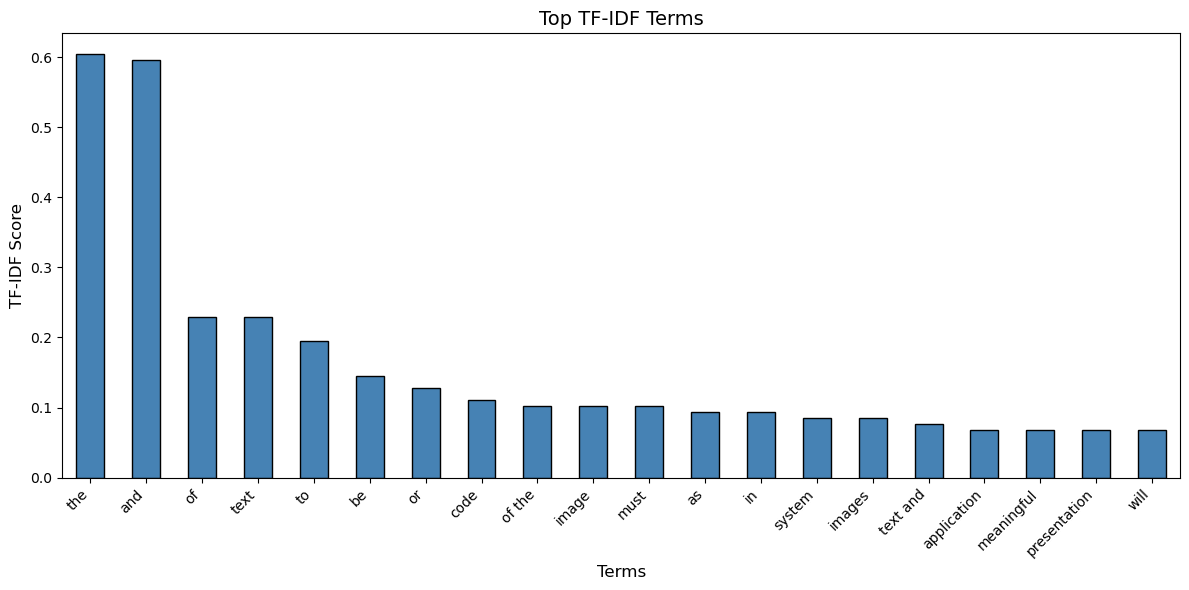

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
#import pandas as pd
import matplotlib.pyplot as plt

# ── 1. Prepare your corpus ────────────────────────────────────────────────────
# Each document is one entry in the list
# For now we have one, but you can simply append more later
#corpus = [processed_text]  # processed_text = " ".join(lemmatised_tokens)
corpus = [full_text]  # 
#corpus = [processed_text, processed_text_doc2, processed_text_doc3]

# ── 2. Initialise and fit the TF-IDF Vectorizer ───────────────────────────────
vectorizer = TfidfVectorizer(
    max_features=20,      # top 20 features
    ngram_range=(1, 2)    # single words and bigrams
)

tfidf_matrix = vectorizer.fit_transform(corpus)

# ── 3. Get feature names and scores ──────────────────────────────────────────
feature_names = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names,
    index=[f"Document {i+1}" for i in range(len(corpus))]
)

print("=== TF-IDF SCORES ===")
print(tfidf_df.round(3))

# ── 4. Top terms ──────────────────────────────────────────────────────────────
top_terms = tfidf_df.T.sort_values("Document 1", ascending=False)

print("\n=== TOP TERMS ===")
print(top_terms)

# ── 5. Visualise ──────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 6))
top_terms["Document 1"].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top TF-IDF Terms', fontsize=14)
plt.xlabel('Terms', fontsize=12)
plt.ylabel('TF-IDF Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Vision

## Sub Heading 1

In [ ]:
# code here...

# Multi-modal

## Sub Heading 1

In [ ]:
# code here

# Final Output

In [ ]:
# code